In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the analysis script importable (it lives next to this notebook).
SCRIPT_DIR = Path.cwd()
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

# Reuse the script's config + cache-loading logic so the notebook and the script
# always agree on which cache entry corresponds to the current settings.
from input_vs_iteration_similarity import MODELS, get_results, PLOTS_DIR

# NOTE: importing the script runs matplotlib.use('Agg') (it's headless-safe), which
# would suppress inline figures. Re-select the inline backend AFTER the import.
%matplotlib inline

/raid/s3/opengptx/behzad_shomali/modalities/olmes/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── ACL/EMNLP single-column style (matches loopMTP_vs_loop.ipynb) ────────────
plt.rcParams.update({
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":      "dejavuserif",
    "font.size":             8,
    "axes.titlesize":        8,
    "axes.labelsize":        8,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7,
    "xtick.labelsize":       7,
    "ytick.labelsize":       7,
    "axes.linewidth":        0.7,
    "xtick.major.width":     0.5,
    "ytick.major.width":     0.5,
    "lines.linewidth":       1.2,
    "figure.dpi":            200,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
})

# Shared visual vocabulary: viridis palette + distinct markers, one entry per model.
PALETTE    = [plt.cm.viridis(v) for v in np.linspace(0.15, 0.75, 2)]
MARKERS    = ["o", "s"]
LINESTYLES = ["-", "-"]
ALPHAS     = [1.0, 0.9]

# Display names used in the paper (keyed by the MODELS spec label).
LABEL_DISPLAY = {"MTP": "w/ MTP", "no-MTP": "wo/ MTP"}

## Load cached results

`get_results(plot_only=True)` reads each model's parquet from `./.similarity_cache`
and raises if a cache entry is missing (run the script once to populate it).
The returned long-form DataFrame has one row per (model, iteration).

In [ ]:
# Markus: you should read it from here: /raid/s3/opengptx/behzad_shomali/modalities/loop_MTP_paper/.similarity_cache
results = get_results(plot_only=True)
results

[MTP] loading cached results from .similarity_cache/MTP_68db0ef2e0.parquet
[no-MTP] loading cached results from .similarity_cache/no-MTP_2e3a9d2b4b.parquet


,label,iteration,mean_cosine,std_cosine,mean_cosine_to_first,std_cosine_to_first
0,MTP,1,0.007240,0.029602,1.000000,3.799066e-08
1,MTP,2,-0.202916,0.072752,-0.202916,7.275176e-02
2,MTP,3,0.948190,0.047381,-0.234860,7.556843e-02
3,MTP,4,0.669609,0.069377,-0.181400,1.137626e-01
4,MTP,5,0.203429,0.175564,0.103025,1.531810e-01
5,no-MTP,1,0.013673,0.039205,1.000000,7.670842e-08
6,no-MTP,2,0.841474,0.068857,0.841474,6.885673e-02
7,no-MTP,3,0.915348,0.056790,0.730236,8.215356e-02
8,no-MTP,4,0.750144,0.072642,0.401917,8.625175e-02
9,no-MTP,5,0.281689,0.140522,0.270730,1.056812e-01


## Plotting helper

Edit freely. `_plot_curve` overlays every model's per-iteration curve for one
metric and returns the `(fig, ax)` so you can tweak it further in the calling cell
(limits, annotations, styling) before saving.

In [4]:
def _plot_curve(results, mean_col, std_col, ylabel, title, figsize=(3.3, 2.2),
                show_err=False, show_legend=True, annotate=True, fmt="{:.2f}", ax=None):
    # Pass an existing `ax` to draw into a shared figure (side-by-side panels);
    # otherwise a standalone single-column figure is created. Returns (fig, ax).
    # `show_err=True` overlays std as (subtle) error bars; off by default to match
    # the clean line style used elsewhere in the paper.
    # `annotate=True` writes each point's value next to it in the series color.
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
    for j, spec in enumerate(MODELS):
        grp = results[results['label'] == spec['label']]
        if grp.empty:
            continue
        name = LABEL_DISPLAY.get(spec['label'], spec['label'])
        color = PALETTE[j % 2]
        kw = dict(
            label=name,
            color=color,
            linestyle=LINESTYLES[j % 2],
            marker=MARKERS[j % 2],
            markersize=3,
            linewidth=1.2,
            alpha=ALPHAS[j % 2],
        )
        if show_err:
            ax.errorbar(grp['iteration'], grp[mean_col], yerr=grp[std_col],
                        capsize=2, elinewidth=0.6, **kw)
        else:
            ax.plot(grp['iteration'], grp[mean_col], **kw)
        if annotate:
            # Nudge the two series in opposite directions so labels don't collide.
            dy = -8 if j == 0 else 4
            for x, y in zip(grp['iteration'], grp[mean_col]):
                ax.annotate(fmt.format(y), (x, y), textcoords="offset points",
                            xytext=(2, dy), fontsize=6, color=color,
                            ha="center", zorder=6,
                            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8)
                            )
    ax.set_title(title, pad=2)
    ax.set_xlabel("Recurrence iteration", labelpad=1)
    ax.set_ylabel(ylabel, labelpad=1)
    ax.set_xticks(sorted(results['iteration'].unique()))
    ax.set_yticks(np.arange(-0.2, 1.01, 0.2))
    ax.tick_params(length=2, pad=1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
    ax.set_axisbelow(True)
    if show_legend:
        ax.legend(frameon=True, framealpha=0.8, edgecolor="#cccccc", handlelength=1.6)
    fig.tight_layout(pad=0.3)
    return fig, ax

## Figure 1 — per-iteration input vs. output similarity

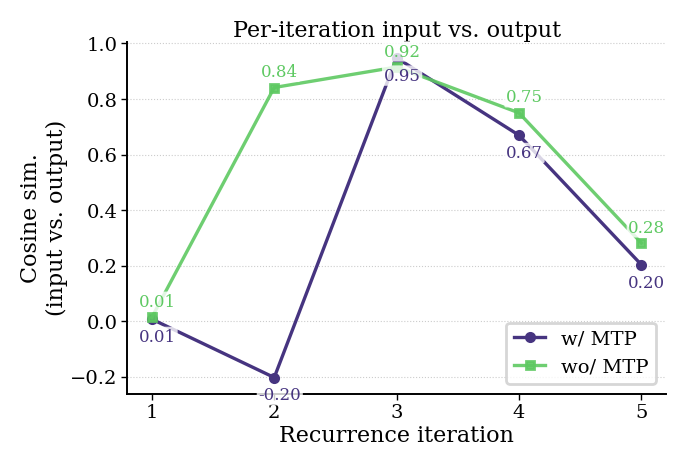

In [5]:
fig, ax = _plot_curve(
    results,
    mean_col='mean_cosine',
    std_col='std_cosine',
    ylabel='Cosine sim.\n(input vs. output)',
    title='Per-iteration input vs. output',
)
# --- tweak the figure here (ax.set_ylim(...), annotations, ...) ---
PLOTS_DIR.mkdir(exist_ok=True)
fig.savefig(PLOTS_DIR / 'per_iteration_input_vs_output_similarity_mtp_vs_nomtp.pdf')
plt.show()

## Figure 2 — first-iteration output vs. later-iteration output similarity

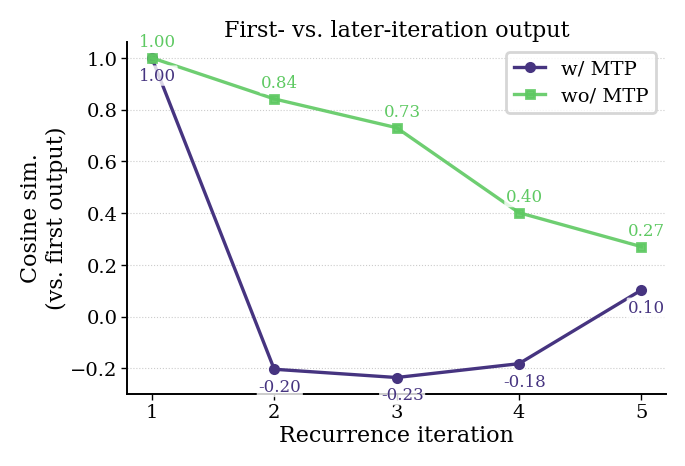

In [6]:
fig, ax = _plot_curve(
    results,
    mean_col='mean_cosine_to_first',
    std_col='std_cosine_to_first',
    ylabel='Cosine sim.\n(vs. first output)',
    title='First- vs. later-iteration output',
)
# --- tweak the figure here ---
fig.savefig(PLOTS_DIR / 'per_iteration_output_vs_first_output_similarity_mtp_vs_nomtp.pdf')
plt.show()

## Combined figure — both panels side by side

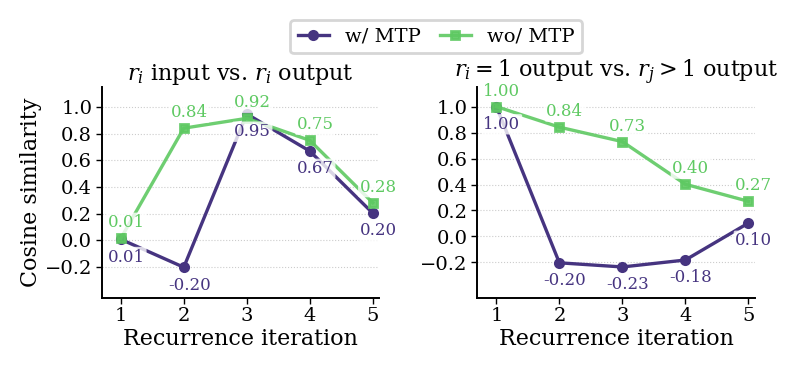

In [7]:
# Two panels side by side, sized for a single text column (~3.3in wide),
# with one shared legend on top (matching loopMTP_vs_loop.ipynb).
fig, axes = plt.subplots(1, 2, figsize=(4, 1.7))

_plot_curve(
    results,
    mean_col='mean_cosine',
    std_col='std_cosine',
    # ylabel='Cosine sim.\n(input vs. output)',
    ylabel='Cosine similarity',
    title='$r_i$ input vs. $r_i$ output',
    ax=axes[0],
    show_legend=False,
)
_plot_curve(
    results,
    mean_col='mean_cosine_to_first',
    std_col='std_cosine_to_first',
    # ylabel='Cosine sim.\n(vs. first output)',
    ylabel='Cosine sim.',
    title='$r_i=1$ output vs. $r_j>1$ output',
    ax=axes[1],
    show_legend=False,
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.55, 1.07),
    ncol=len(handles),
    columnspacing=1.0,
    handlelength=1.6,
    frameon=True,
    framealpha=0.8,
    edgecolor="#cccccc",
)

# axes[0].set_xlabel("")
axes[1].set_ylabel("")
axes[0].set_ylim(-.43, 1.15)
axes[1].set_ylim(-.47, 1.15)
axes[0].set_xlim(0.7, 5.1)
axes[1].set_xlim(0.7, 5.1)

fig.tight_layout()
PLOTS_DIR.mkdir(exist_ok=True)
fig.savefig(PLOTS_DIR / 'per_iteration_similarity_combined_mtp_vs_nomtp.pdf', bbox_inches="tight")
plt.show()

## Combined figure — bar-plot variants
### <b>!!! Comment to Markus:</b> Maybe the following style demonstrates the differences in similarity more clearly than the curves above

Same two panels and metrics as above, but drawn as grouped bars (one bar per model
per iteration) instead of curves. Two flavours: vertical bars and horizontal bars.

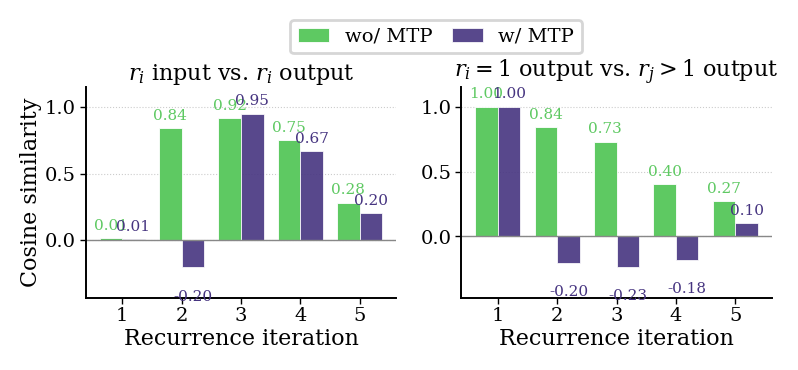

In [9]:
def _plot_bars(results, mean_col, std_col, ylabel, title, ax,
               orientation="vertical", show_err=False, annotate=True,
               fmt="{:.2f}", bar_width=0.38):
    # Grouped bars: for each iteration, one bar per model, mirroring `_plot_curve`'s
    # palette / display names. `orientation="horizontal"` draws barh (iteration on y).
    iters = sorted(results['iteration'].unique())
    pos = np.arange(len(iters))
    n = len(MODELS)
    for j, spec in enumerate(MODELS[::-1]):
        grp = results[results['label'] == spec['label']].set_index('iteration')
        if grp.empty:
            continue
        name = LABEL_DISPLAY.get(spec['label'], spec['label'])
        color = PALETTE[(j+1) % 2]
        vals = np.array([grp[mean_col].get(it, np.nan) for it in iters])
        errs = np.array([grp[std_col].get(it, np.nan) for it in iters])
        # Offset each model's bars symmetrically around the group centre.
        off = (j - (n - 1) / 2) * bar_width
        if orientation == "horizontal":
            ax.barh(pos + off, vals, height=bar_width, color=color, label=name,
                    alpha=ALPHAS[j % 2], edgecolor="white", linewidth=0.3,
                    xerr=errs if show_err else None,
                    error_kw=dict(elinewidth=0.6, capsize=2))
            if annotate:
                for p, v in zip(pos + off, vals):
                    ax.annotate(fmt.format(v), (v, p), textcoords="offset points",
                                xytext=(3 if v >= 0 else -3, 0), fontsize=5.5,
                                color=color, va="center",
                                ha="left" if v >= 0 else "right", zorder=6)
        else:
            ax.bar(pos + off, vals, width=bar_width, color=color, label=name,
                   alpha=ALPHAS[j % 2], edgecolor="white", linewidth=0.3,
                   yerr=errs if show_err else None,
                   error_kw=dict(elinewidth=0.6, capsize=2))
            if annotate:
                for p, v in zip(pos + off, vals):
                    ax.annotate(fmt.format(v), (p, v), textcoords="offset points",
                                xytext=(0, 2 if v >= 0 else -8), fontsize=5.5,
                                color=color, ha="center",
                                va="bottom" if v >= 0 else "top", zorder=6)
    ax.set_title(title, pad=2)
    if orientation == "horizontal":
        ax.set_yticks(pos)
        ax.set_yticklabels(iters)
        ax.set_ylabel("Recurrence iteration", labelpad=1)
        ax.set_xlabel(ylabel, labelpad=1)
        ax.invert_yaxis()  # iteration 1 on top
        ax.xaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
        ax.axvline(0, color="#888888", linewidth=0.5)
    else:
        ax.set_xticks(pos)
        ax.set_xticklabels(iters)
        ax.set_xlabel("Recurrence iteration", labelpad=1)
        ax.set_ylabel(ylabel, labelpad=1)
        ax.yaxis.grid(True, linestyle=":", linewidth=0.4, alpha=0.6, color="#aaaaaa")
        ax.axhline(0, color="#888888", linewidth=0.5)
    ax.tick_params(length=2, pad=1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    return ax


# --- vertical grouped bars ------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(4, 1.7))
_plot_bars(results, 'mean_cosine', 'std_cosine', 'Cosine similarity',
           '$r_i$ input vs. $r_i$ output', ax=axes[0])
_plot_bars(results, 'mean_cosine_to_first', 'std_cosine_to_first', 'Cosine sim.',
           '$r_i=1$ output vs. $r_j>1$ output', ax=axes[1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.55, 1.07),
           ncol=len(handles), columnspacing=1.0, handlelength=1.6,
           frameon=True, framealpha=0.8, edgecolor="#cccccc")

axes[1].set_ylabel("")
axes[0].set_ylim(-.43, 1.15)
axes[1].set_ylim(-.47, 1.15)

fig.tight_layout()
PLOTS_DIR.mkdir(exist_ok=True)
fig.savefig(PLOTS_DIR / 'per_iteration_similarity_combined_bars_vertical_mtp_vs_nomtp.pdf',
            bbox_inches="tight")
plt.show()